Défi quotidien : Gestion et analyse des données en Python

Shape : (1171, 6)
        job_title   job_type experience_level       location salary_currency  \
0  Data scientist  Full Time           Senior  New York City             USD   
1  Data scientist  Full Time           Senior         Boston             USD   
2  Data scientist  Full Time           Senior         London             USD   
3  Data scientist  Full Time           Senior         Boston             USD   
4  Data scientist  Full Time           Senior  New York City             USD   

   salary  
0  149000  
1  120000  
2   68000  
3  120000  
4  149000  

--- Normalisation Min-Max ---
Salary original  → min : 30,000  | max : 228,000
Salary normalisé → min : 0.00 | max : 1.00

--- PCA ---
Variance expliquée par chaque composante : [1. 0.]
Variance totale expliquée : 100.0%


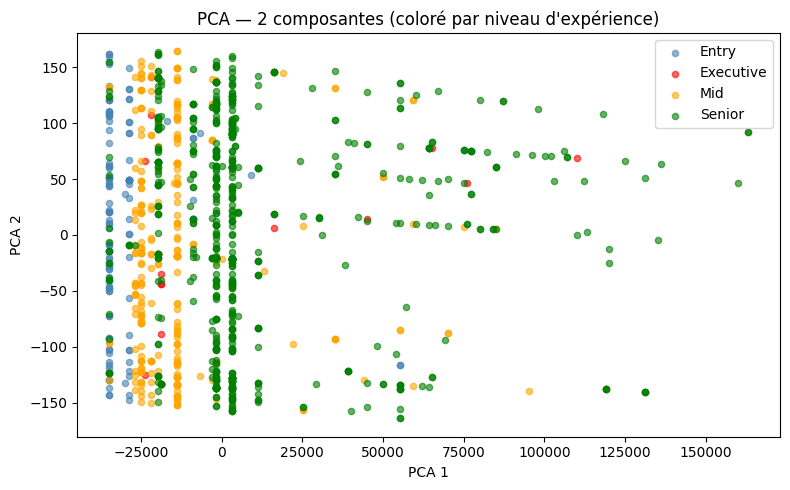


--- Salaire moyen et médian par niveau d'expérience ---
                  salaire_moyen  salaire_median  nb_emplois
experience_level                                           
Entry                  36111.11         30000.0         126
Mid                    51786.89         51000.0         305
Senior                 75088.03         68000.0         727
Executive              76076.92         46000.0          13


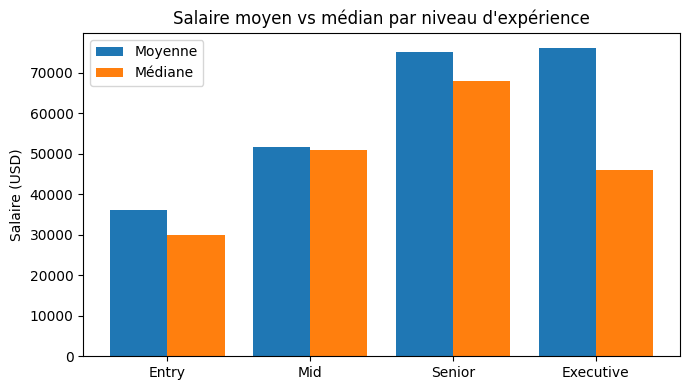

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==========================================
# 0. CHARGEMENT
# ==========================================
df = pd.read_csv("datascience_salaries.csv")
df = df.drop(columns=["Unnamed: 0"])  # index inutile
print("Shape :", df.shape)
print(df.head())


# ==========================================
# 1. NORMALISATION MIN-MAX DU SALAIRE
# ==========================================
scaler = MinMaxScaler()
df["salary_normalized"] = scaler.fit_transform(df[["salary"]])

print("\n--- Normalisation Min-Max ---")
print(f"Salary original  → min : {df['salary'].min():,}  | max : {df['salary'].max():,}")
print(f"Salary normalisé → min : {df['salary_normalized'].min():.2f} | max : {df['salary_normalized'].max():.2f}")


# ==========================================
# 2. RÉDUCTION DE DIMENSIONNALITÉ — PCA
# ==========================================
# PCA nécessite des colonnes numériques uniquement.
# On encode les catégorielles avant de réduire.

df_pca = df.copy()

# Encoder les colonnes catégorielles
le = LabelEncoder()
for col in ["job_title", "job_type", "experience_level", "location", "salary_currency"]:
    df_pca[col] = le.fit_transform(df_pca[col])

# Sélectionner toutes les features numériques (hors salary_normalized qui est dérivé)
features = ["job_title", "job_type", "experience_level",
            "location", "salary_currency", "salary"]
X = df_pca[features]

# Appliquer PCA → réduire à 2 composantes pour visualisation
pca = PCA(n_components=2)
components = pca.fit_transform(X)

df["PCA_1"] = components[:, 0]
df["PCA_2"] = components[:, 1]

print("\n--- PCA ---")
print(f"Variance expliquée par chaque composante : {pca.explained_variance_ratio_.round(3)}")
print(f"Variance totale expliquée : {pca.explained_variance_ratio_.sum():.1%}")

# Visualisation PCA colorée par experience_level
colors = {"Entry": "steelblue", "Mid": "orange", "Senior": "green", "Executive": "red"}
fig, ax = plt.subplots(figsize=(8, 5))
for level, group in df.groupby("experience_level"):
    ax.scatter(group["PCA_1"], group["PCA_2"],
               label=level, alpha=0.6, s=20, color=colors[level])
ax.set_title("PCA — 2 composantes (coloré par niveau d'expérience)")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.legend()
plt.tight_layout()
plt.show()


# ==========================================
# 3. AGRÉGATION PAR NIVEAU D'EXPÉRIENCE
# ==========================================
aggregation = df.groupby("experience_level")["salary"].agg(
    salaire_moyen="mean",
    salaire_median="median",
    nb_emplois="count"
).round(2)

# Trier du moins expérimenté au plus expérimenté
ordre = ["Entry", "Mid", "Senior", "Executive"]
aggregation = aggregation.reindex(ordre)

print("\n--- Salaire moyen et médian par niveau d'expérience ---")
print(aggregation)

# Visualisation
fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(aggregation))
ax.bar(x, aggregation["salaire_moyen"],  width=0.4, label="Moyenne", align="center")
ax.bar([i + 0.4 for i in x], aggregation["salaire_median"], width=0.4, label="Médiane", align="center")
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(aggregation.index)
ax.set_title("Salaire moyen vs médian par niveau d'expérience")
ax.set_ylabel("Salaire (USD)")
ax.legend()
plt.tight_layout()
plt.show()